In [27]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_path = "./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"

In [28]:
print(os.listdir(data_path))

['FakeVideo-FakeAudio', 'FakeVideo-RealAudio', 'meta_data.csv', 'README.txt', 'RealVideo-FakeAudio', 'RealVideo-RealAudio']


In [29]:
video_paths = []
labels = []

for category in os.listdir(data_path):
    category_path = os.path.join(data_path, category)

    if not os.path.isdir(category_path):
        continue

    # Assign label
    if "FakeVideo" in category:
        label = 0
    elif "RealVideo" in category:
        label = 1
    else:
        continue

    for race in os.listdir(category_path):
        race_path = os.path.join(category_path, race)

        for gender in os.listdir(race_path):
            gender_path = os.path.join(race_path, gender)

            for video_folder in os.listdir(gender_path):
                video_folder_path = os.path.join(gender_path, video_folder)

                for file in os.listdir(video_folder_path):
                    if file.endswith(".mp4"):
                        full_path = os.path.join(video_folder_path, file)
                        video_paths.append(full_path)
                        labels.append(label)

print("Total videos:", len(video_paths))

Total videos: 21544


## Testing to see if we can find a fake video

In [30]:
print(video_paths[0]) #find video path
print(labels[0]) # 0 for fake, 1 for real

./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2\FakeVideo-FakeAudio\African\men\id00076\00109_10_id00476_wavtolip.mp4
0


## This was just to see if we can transverse through multiple files finding real videos whether its from fake audio or not because we don't care for audio

In [48]:
import random

real_indices = [i for i in range(len(labels)) if labels[i] == 1]

random_index = random.choice(real_indices)

print("Random real video:")
print(video_paths[random_index])

Random real video:
./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2\RealVideo-RealAudio\Asian (East)\women\id00935\00005.mp4


## Here we test on 20% of the data and we train on 80% of the data.

In [126]:
from sklearn.model_selection import train_test_split

video_train, video_test, label_train, label_test = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42
)

## We now set up the frames and resize before CNN.

In [127]:
import cv2

def extract_frames(video_path, max_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames)
    
    for i in range(max_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frames.append(frame)

    cap.release()
    return frames

## We train on limited data and then we test on entire data

In [128]:
X_train = []
y_train = []
video_source_train = []

fake_count = 0
real_count = 0
max_per_class = 1500 

for i in range(len(video_train)):

    # --- control FAKE ---
    if label_train[i] == 0:
        if fake_count >= max_per_class:
            continue
        fake_count += 1

    # --- control REAL ---
    elif label_train[i] == 1:
        if real_count >= max_per_class:
            continue
        real_count += 1

    frames = extract_frames(video_train[i])

    for frame in frames:
        frame = cv2.resize(frame, (128,128))
        frame = frame / 255.0

        X_train.append(frame)
        y_train.append(label_train[i])
        video_source_train.append(video_train[i])

# convert to numpy
X_train = np.array(X_train)
y_train = np.array(y_train)

print("Train shape:", X_train.shape)
print("Fake count:", fake_count)
print("Real count:", real_count)

Train shape: (11365, 128, 128, 3)
Fake count: 1500
Real count: 773


In [129]:
X_test, y_test = [], []
video_source_test = []

for i in range(len(video_test)):
    frames = extract_frames(video_test[i])

    for frame in frames:
        frame = cv2.resize(frame, (128,128))
        frame = frame / 255.0

        X_test.append(frame)
        y_test.append(label_test[i])
        video_source_test.append(video_test[i])
        
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test shape:", X_test.shape)

Test shape: (21545, 128, 128, 3)


In [130]:
from sklearn.utils import shuffle

# Training set
X_train, y_train, video_source_train = shuffle(
    X_train, y_train, video_source_train, random_state=42
)

# Test set
X_test, y_test, video_source_test = shuffle(
    X_test, y_test, video_source_test, random_state=42
)

## This section is CNN set up, Conv layers they detect the patterns such as textures, fakes and edges. pooling reduces the size and keeps the relevant informations and dense will be the decision maker of if its real or fake.

In [131]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [132]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [133]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    X_train, y_train,
    epochs=20,  # allow more, it will stop early
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.6576 - loss: 0.6455 - val_accuracy: 0.9473 - val_loss: 0.4231
Epoch 2/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6598 - loss: 0.6339 - val_accuracy: 0.9444 - val_loss: 0.4222
Epoch 3/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.6724 - loss: 0.6012 - val_accuracy: 0.9360 - val_loss: 0.3100
Epoch 4/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.7223 - loss: 0.5313 - val_accuracy: 0.8652 - val_loss: 0.3184
Epoch 5/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.7646 - loss: 0.4619 - val_accuracy: 0.7482 - val_loss: 0.4973
Epoch 6/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.8083 - loss: 0.3999 - val_accuracy: 0.8867 - val_loss: 0.2692
Epoch 7/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.8303 - loss: 0.3686 - val_accuracy: 0.8975 - val_loss: 0.2480
Epoch 8/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.8613 - loss: 0.3135 - 

In [136]:
# Step 1: predictions
y_pred = model.predict(X_test)

# Step 2: compute ROC + EER
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
fnr = 1 - tpr

eer_index = np.nanargmin(np.abs(fpr - fnr))
eer_threshold = thresholds[eer_index]

print(f"EER: {fpr[eer_index]:.4f}")
print(f"Threshold at EER: {eer_threshold:.4f}")

# Step 3: apply threshold
y_pred_labels = (y_pred > eer_threshold).astype(int)


674/674 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
EER: 0.2257
Threshold at EER: 0.2236


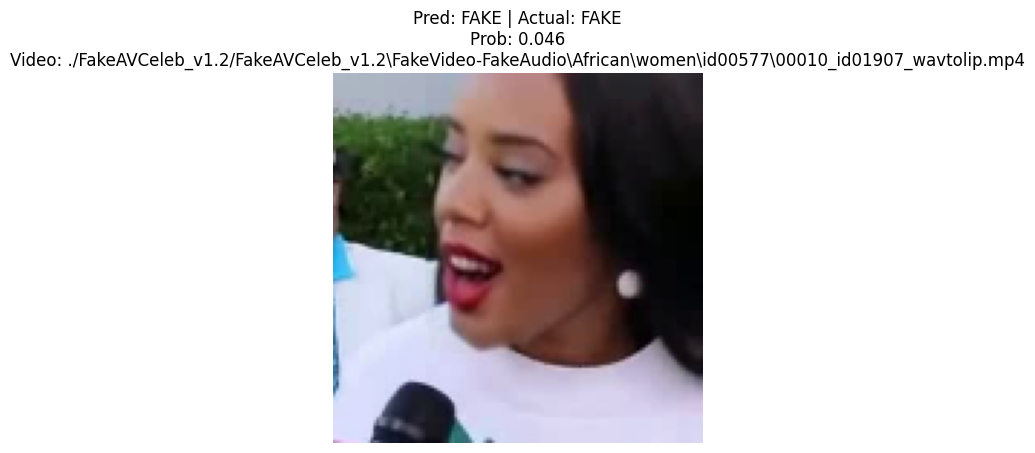

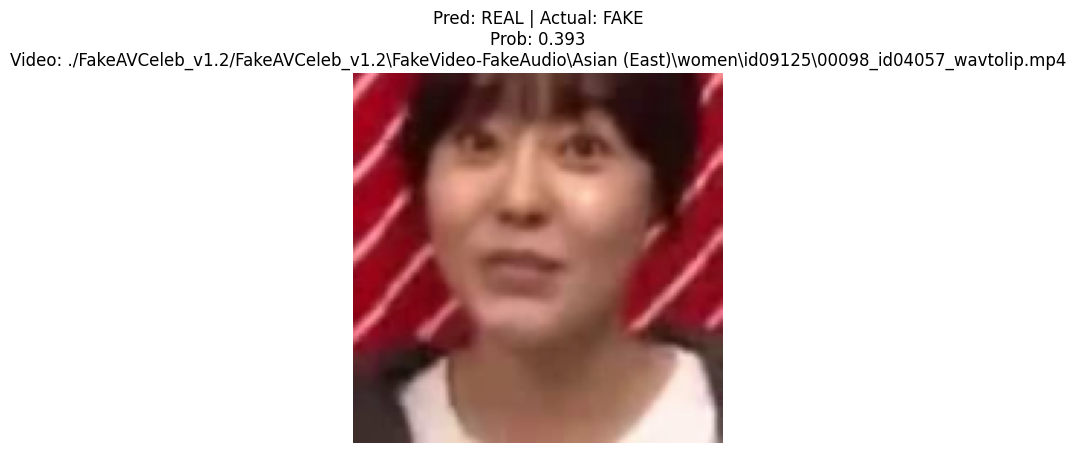

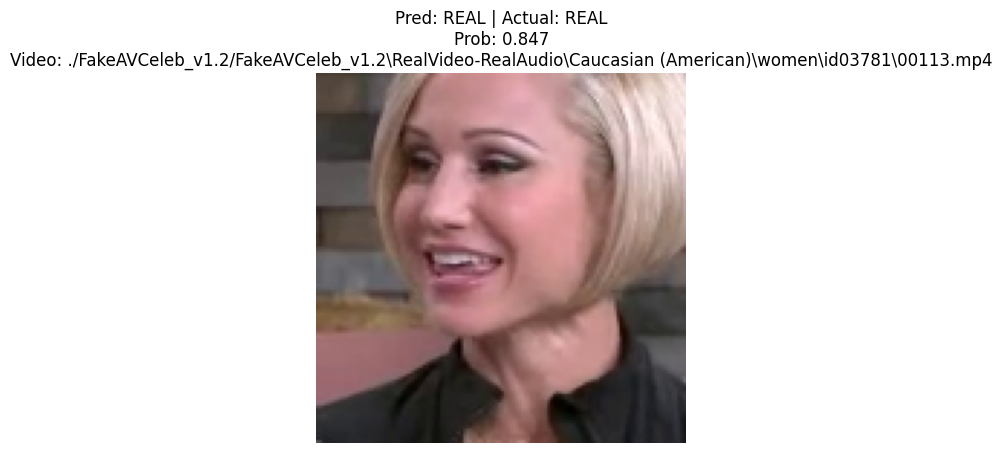

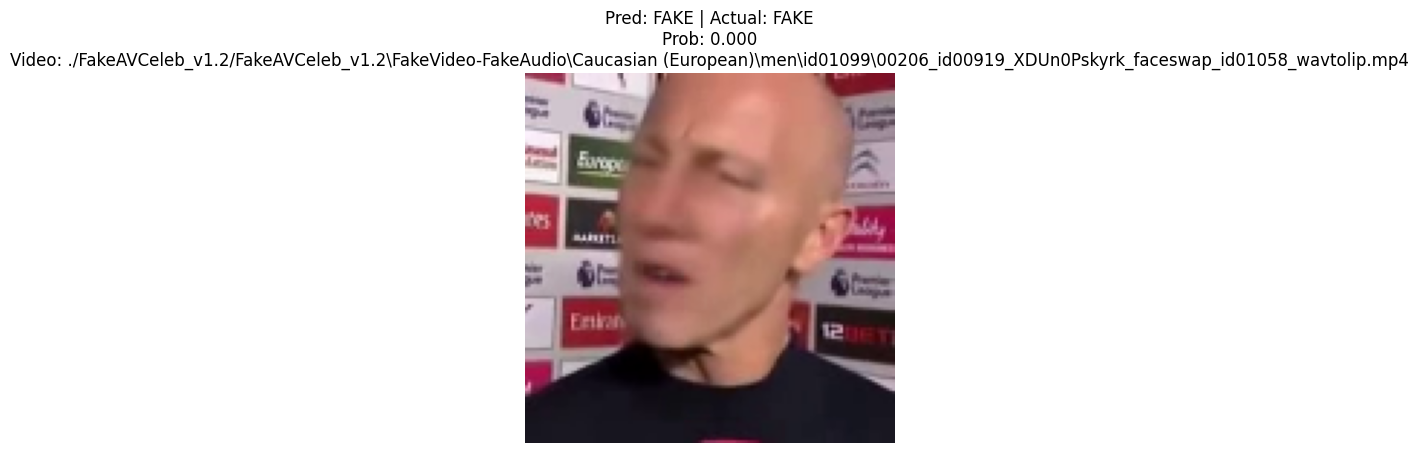

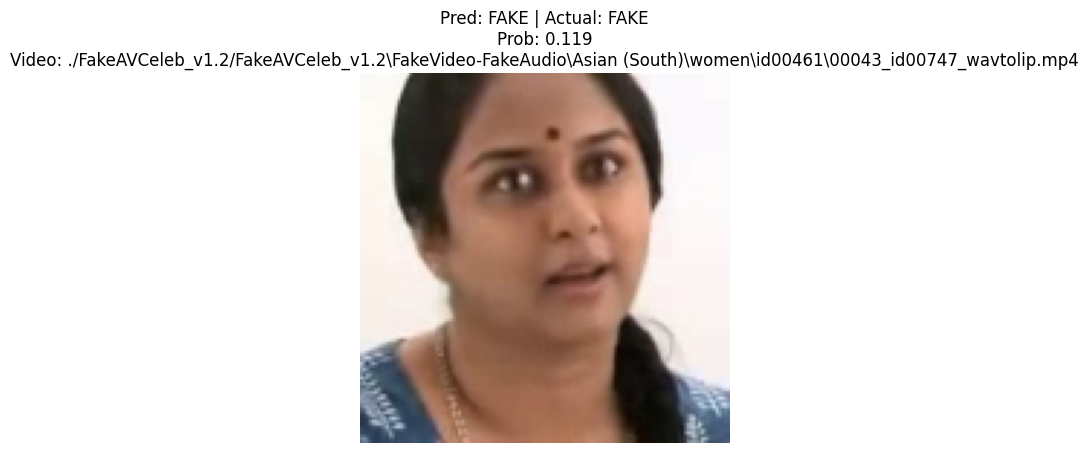

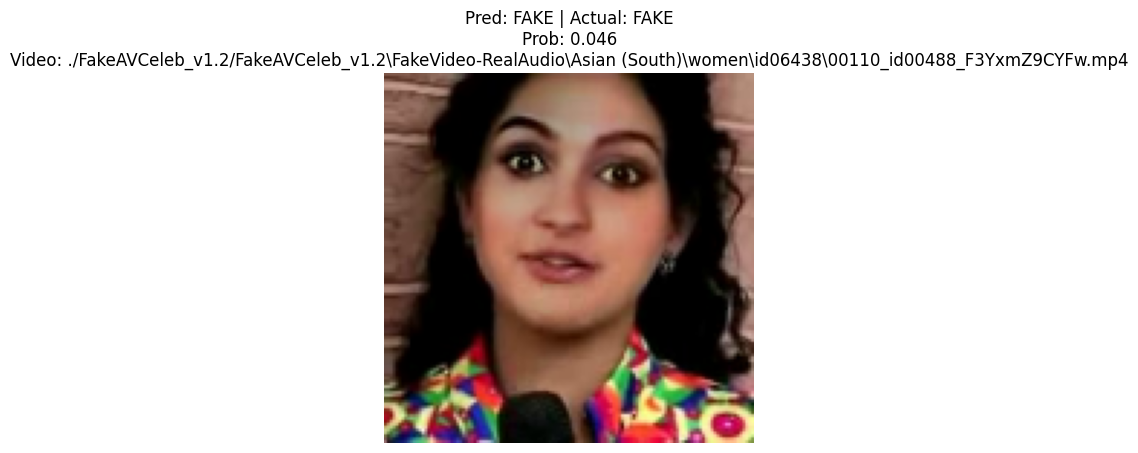

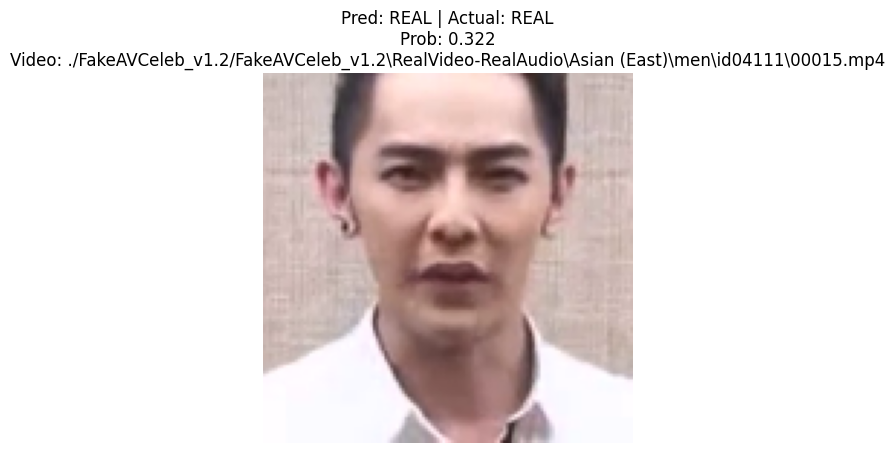

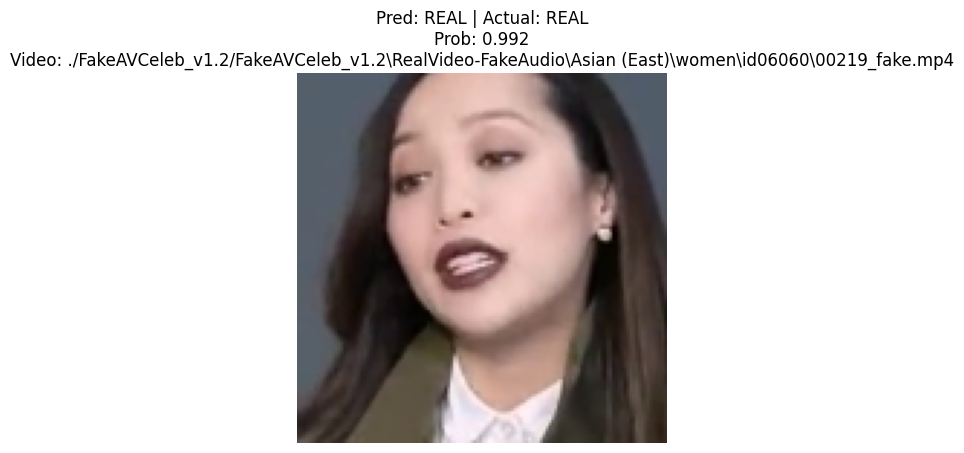

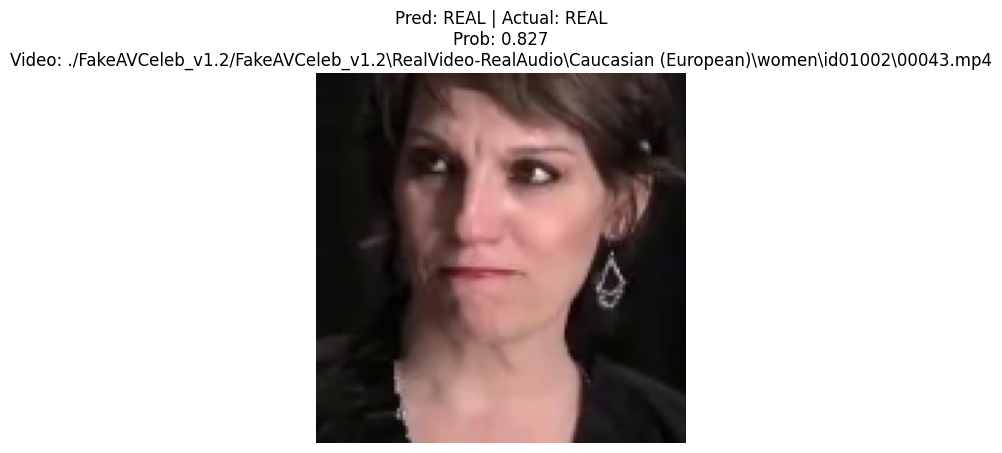

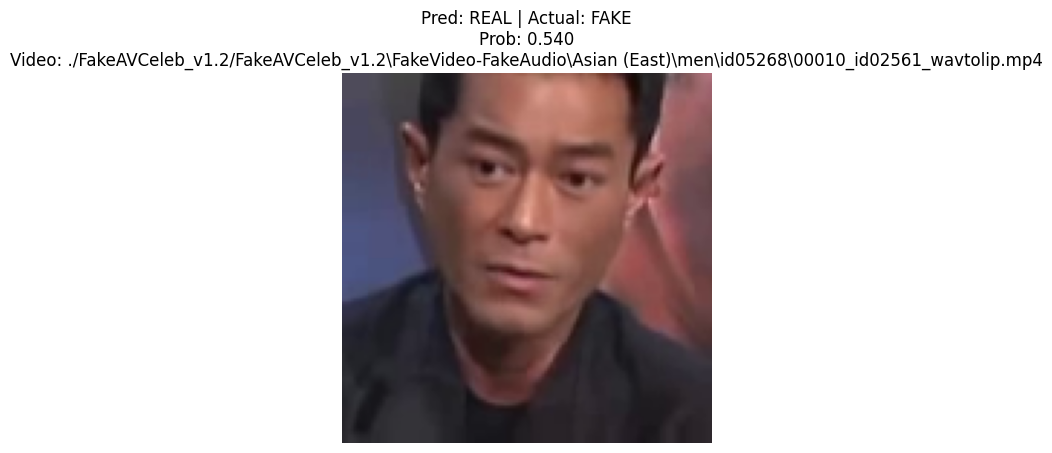

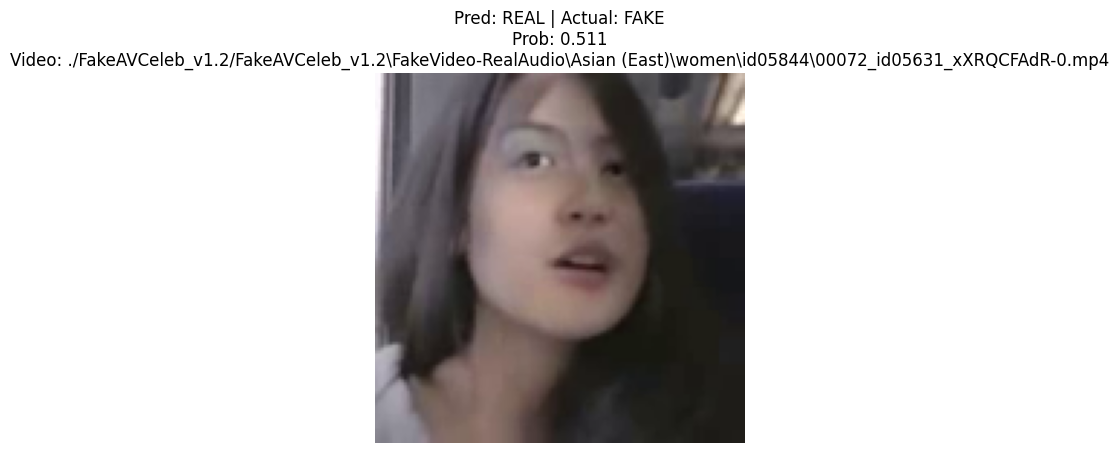

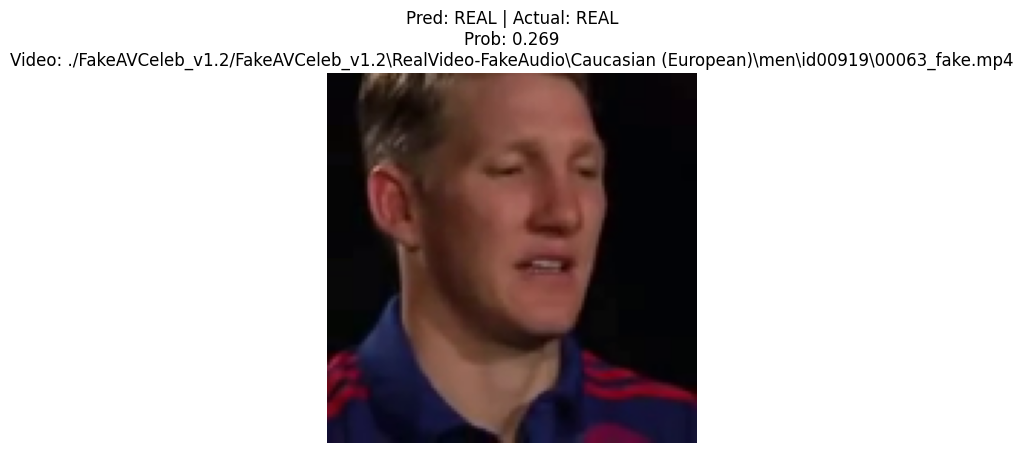

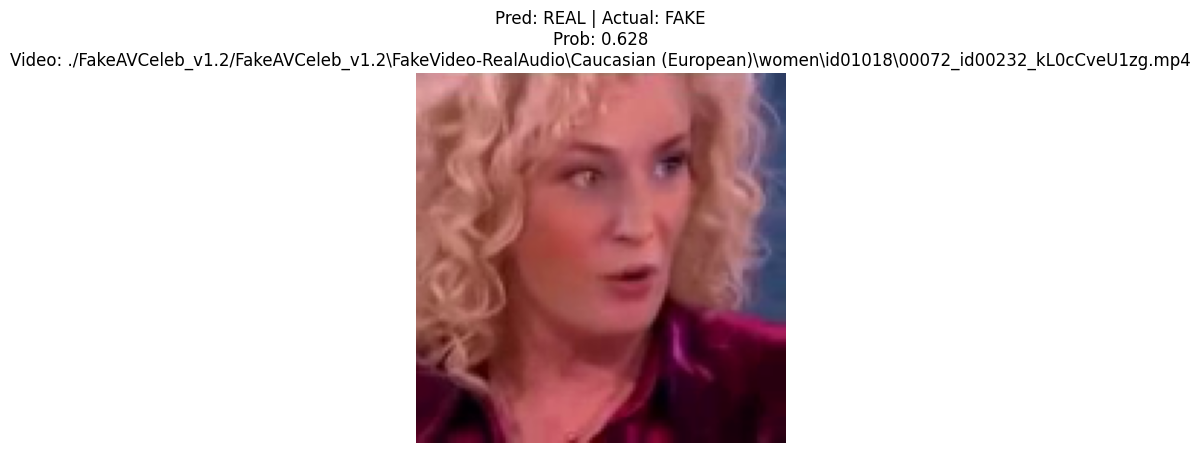

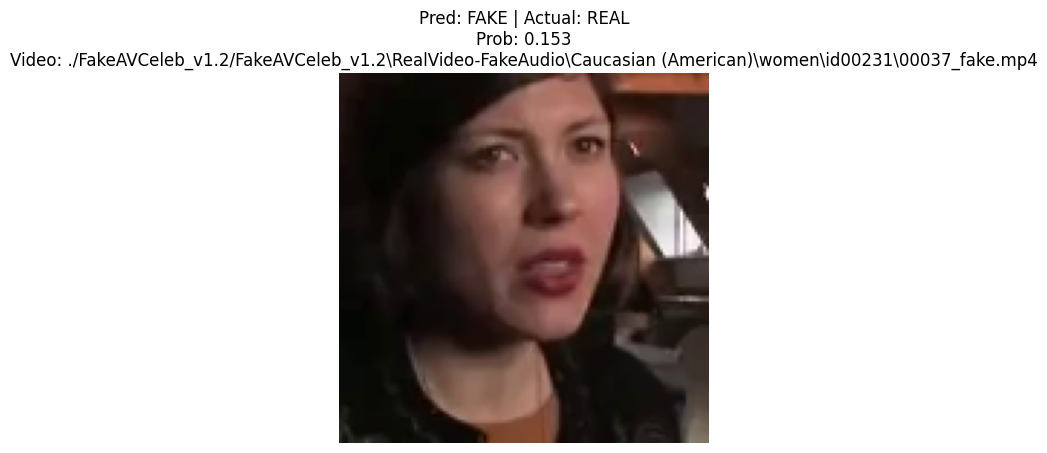

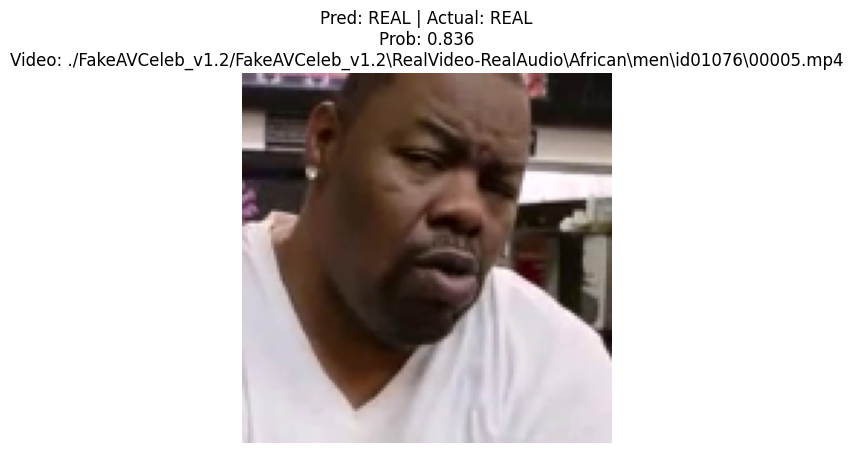

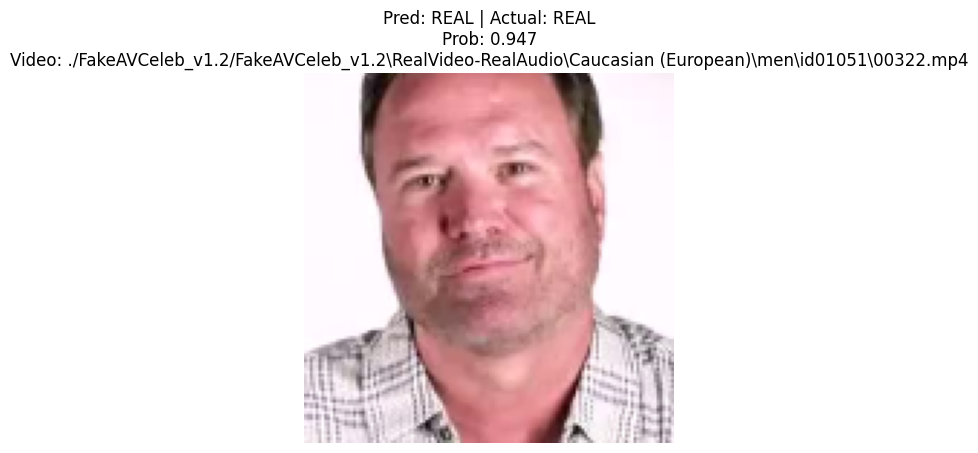

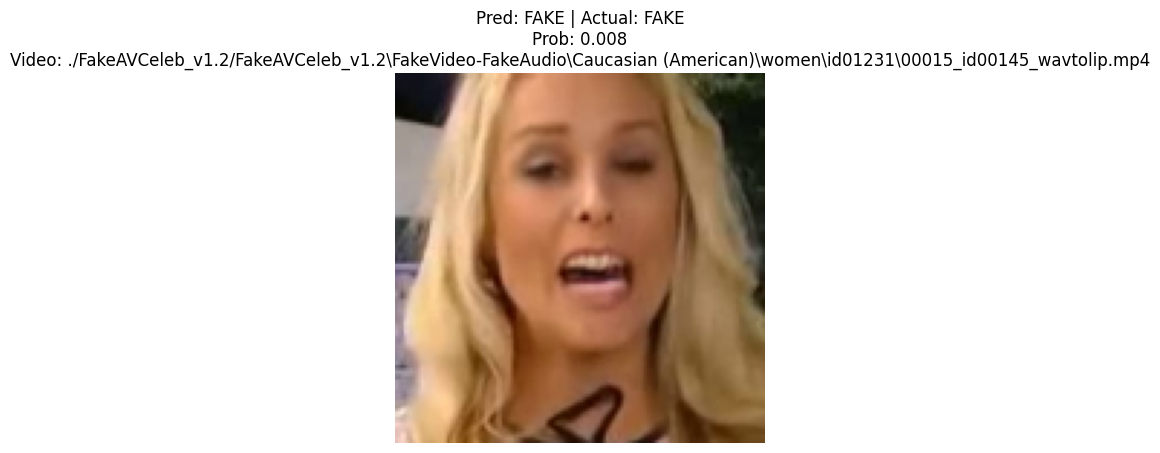

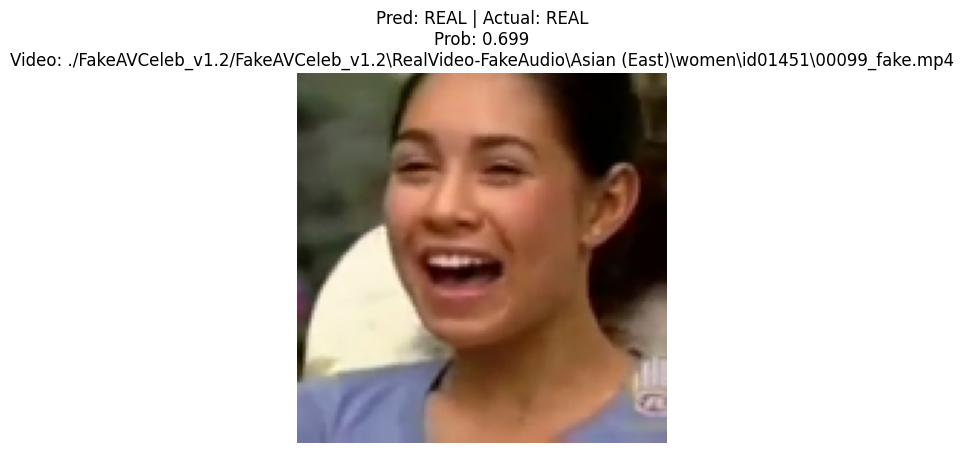

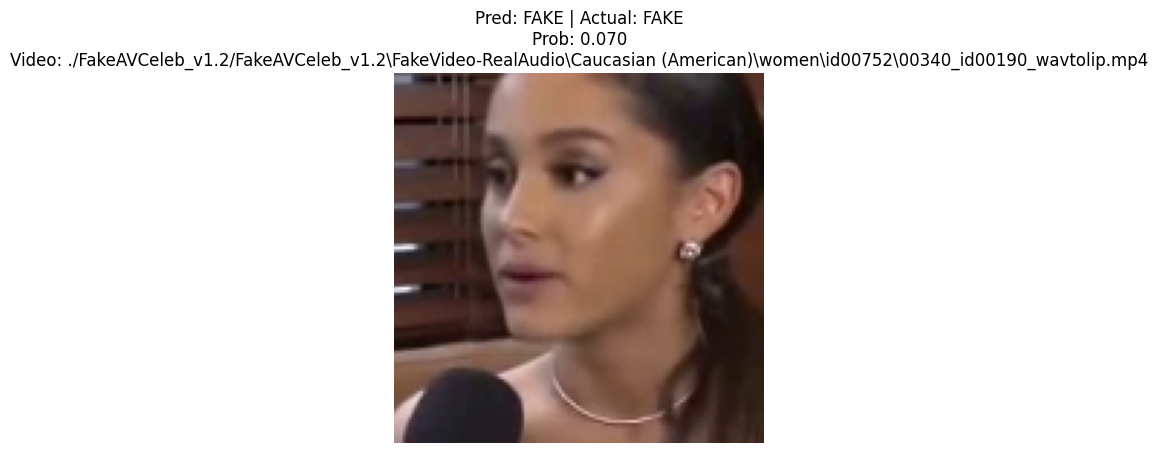

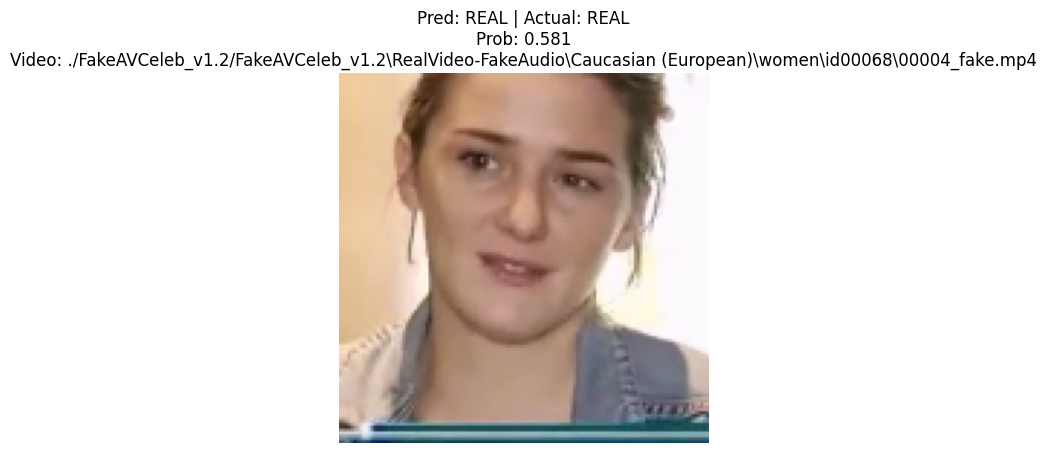

In [137]:
import random
import matplotlib.pyplot as plt

label_map = {0: "FAKE", 1: "REAL"}

# indices = random.sample(range(len(X_test)), 20)  # pick 20 random samples

real_indices = [i for i in range(len(y_test)) if y_test[i] == 1]
fake_indices = [i for i in range(len(y_test)) if y_test[i] == 0]

indices = random.sample(real_indices, 10) + random.sample(fake_indices, 10)
random.shuffle(indices)

for i in indices:
    img = cv2.cvtColor((X_test[i]*255).astype('uint8'), cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(
    f"Pred: {label_map[y_pred_labels[i][0]]} | "
    f"Actual: {label_map[y_test[i]]}\n"
    f"Prob: {y_pred[i][0]:.3f}\n"
    f"Video: {video_source_test[i]}"
)
    plt.axis('off')
    plt.show()

In [138]:
correct = 0
wrong = 0

for i in indices:
    pred = y_pred_labels[i][0]
    actual = y_test[i]

    if pred == actual:
        correct += 1
    else:
        wrong += 1

print("Correct:", correct)
print("Wrong:", wrong)
print("Accuracy:", correct / (correct + wrong))

Correct: 15
Wrong: 5
Accuracy: 0.75


## Confusion Matrix 
TN = Fake -> Fake, <br>
FP = Fake -> Real, <br>
FN = Real -> Fake, <br>
TP = Real -> Real.

In [139]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

Confusion Matrix:
 [[15805  4605]
 [  256   879]]
TN: 15805, FP: 4605, FN: 256, TP: 879


### (Previous calculation) so from this we see accuracy = (TP + TN) / (TP + TN + FP + FN) = (523 + 18909)/ (18909 + 523 + 612 + 1501) = 0.901

In [140]:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
FAR = FP / (FP + TN)
FRR = FN / (FN + TP)

print(f"Accuracy: {Accuracy:.3f}")
print(f"False Acceptance Rate (FAR): {FAR:.3f}")
print(f"False Rejection Rate (FRR): {FRR:.3f}")

Accuracy: 0.774
False Acceptance Rate (FAR): 0.226
False Rejection Rate (FRR): 0.226


In [141]:
from sklearn.metrics import roc_curve
import numpy as np

# IMPORTANT: use probabilities, NOT labels
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
fnr = 1 - tpr

eer_index = np.nanargmin(np.abs(fpr - fnr))

eer = fpr[eer_index]
eer_threshold = thresholds[eer_index]

print(f"EER: {eer:.4f}")
print(f"Threshold at EER: {eer_threshold:.4f}")

EER: 0.2257
Threshold at EER: 0.2236


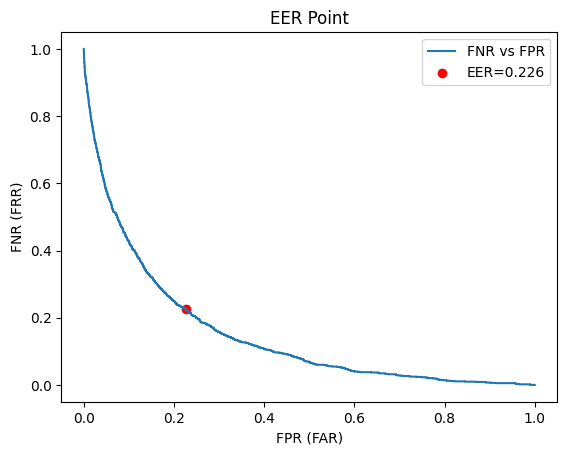

In [142]:
import matplotlib.pyplot as plt

plt.plot(fpr, fnr, label="FNR vs FPR")
plt.scatter(fpr[eer_index], fnr[eer_index], color='red', label=f"EER={eer:.3f}")

plt.xlabel("FPR (FAR)")
plt.ylabel("FNR (FRR)")
plt.title("EER Point")
plt.legend()
plt.show()

## Testing to see how many videos are within the dataset and comparing if my testing evaluation is correct (ignore if irrelavant just fun testing)

In [143]:
import os

dataset_path = "C:/Users/leeja/Downloads/Deep-Learning-for-Face-Spoofing-Detection/FakeAVCeleb_v1.2"

video_extensions = (".mp4", ".avi", ".mov", ".mkv")

folder_counts = {}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    
    if os.path.isdir(folder_path):
        count = 0
        
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(video_extensions):
                    count += 1
        
        folder_counts[folder] = count

# print results
total = 0
for folder, count in folder_counts.items():
    print(f"{folder}: {count}")
    total += count

print("\nTotal videos:", total)

FakeAVCeleb_v1.2: 21544

Total videos: 21544


In [144]:
print("Train videos:", len(video_train))
print("Test videos:", len(video_test))
print("Total used:", len(video_train) + len(video_test))

Train videos: 17235
Test videos: 4309
Total used: 21544


testing 4309 x 5 = 21545 (checks out) <br>
training 17,235 videos for avaliable pooling but we only used 2,273 videos for training because of class balancing

## Showing Univariate Analysis

In [157]:
import pandas as pd

df = pd.read_csv(r"c:\Users\leeja\Downloads\Deep-Learning-for-Face-Spoofing-Detection\FakeAVCeleb_v1.2\FakeAVCeleb_v1.2\meta_data.csv")

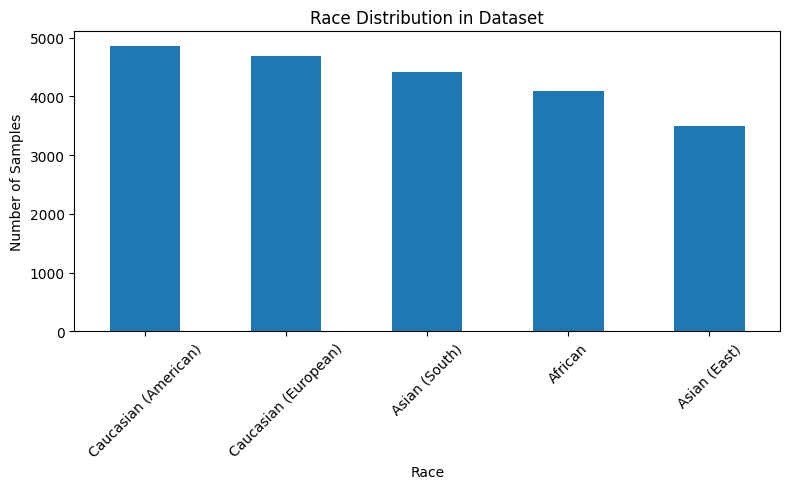

In [158]:
import matplotlib.pyplot as plt

race_counts = df['race'].value_counts()

plt.figure(figsize=(8,5))
race_counts.plot(kind='bar')

plt.title("Race Distribution in Dataset")
plt.xlabel("Race")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

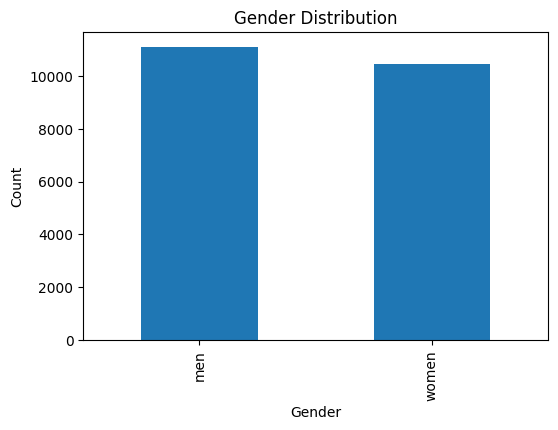

In [159]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,4))
gender_counts.plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Showing Bivariate Analysis

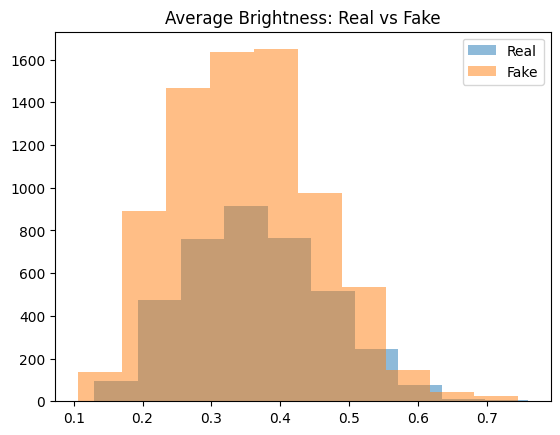

In [146]:
real_pixels = [np.mean(img) for img, label in zip(X_train, y_train) if label == 1]
fake_pixels = [np.mean(img) for img, label in zip(X_train, y_train) if label == 0]

plt.hist(real_pixels, alpha=0.5, label="Real")
plt.hist(fake_pixels, alpha=0.5, label="Fake")
plt.legend()
plt.title("Average Brightness: Real vs Fake")
plt.show()

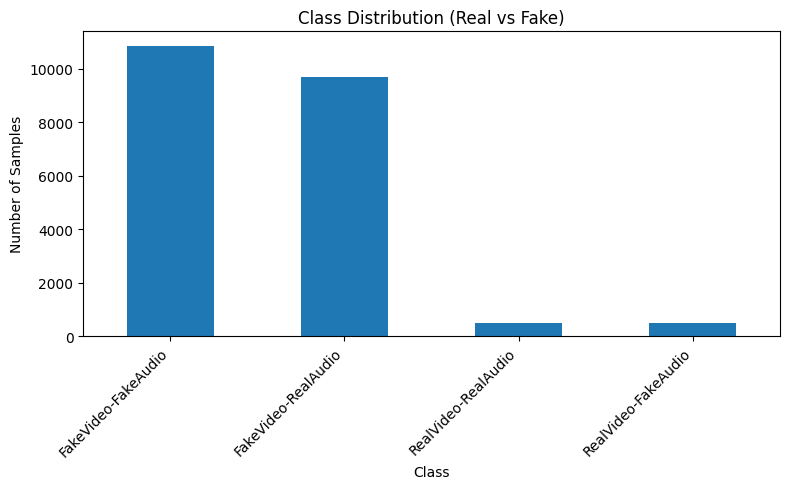

In [ ]:
import matplotlib.pyplot as plt

class_counts = df['type'].value_counts()   # or 'label' depending on your dataset

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')

plt.title("Class Distribution (Real vs Fake)")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

plt.show()